# Merchandising Customer Insights

## STAGE 1: Business Understanding

### Step 1.1 — Problem Definition

#### Business Context
Nordstrom's Customer Insights & Analytics team supports merchandising and marketing leadership across four channels.
Recent executive reviews have flagged three interconnected concerns: repeat purchase rates are declining, promotional
spend is increasing, and category-level revenue is underperforming plan in key segments.

#### Problem Statement
"Nordstrom needs to understand who its most valuable customers are, whether they are being retained or lost, and whether promotional activity is helping or hurting long-term customer behavior. The business suspects that heavy promotions are attracting price-sensitive customers who do not return at full price — masking a structural decline in loyal customer engagement."

### Step 1.2 Success Criteria

#### Objectives

* Segmentation — Build a behavioral customer segmentation using RFM and purchase signals that identifies distinct customer types and their category affinities
* Churn & Retention — Identify which segments are at highest risk of churning, quantify the revenue at risk, and surface the behavioral signals that predict churn
* Promotional Incrementality — Determine whether promotional periods drive net new revenue or cannibalize / pull forward demand, and whether promotions disproportionately attract low-retention customers

#### Success Criteria

Segments are actionable and defensible to a non-technical merchandising leader
Churn model identifies at-risk customers with enough lead time to intervene
Promotional analysis produces a clear ship / don't ship / redesign recommendation with dollar impact

## Stage 2: Data Understanding

#### Column Definitions

| Column | Data Type | Description | Example Values | Notes |
|--------|-----------|-------------|----------------|-------|
| **InvoiceNo** | String | Unique transaction identifier | `536365`, `C536379` | Prefix `C` indicates cancellation/return |
| **StockCode** | String | Product (SKU) identifier | `85123A`, `22423` | Alphanumeric |
| **Description** | String | Product name | `WHITE HANGING HEART T-LIGHT HOLDER` | Free text |
| **Quantity** | Integer | Number of units purchased | `6`, `-1` | Can be negative |
| **InvoiceDate** | DateTime | Transaction timestamp | `2010-12-01 08:26:00` | Format: YYYY-MM-DD HH:MM:SS |
| **UnitPrice** | Float | Price per unit in GBP (£) | `2.55`, `3.39` | Price per unit |
| **CustomerID** | Float | Unique customer identifier | `17850.0`, `NaN` | Can be missing |
| **Country** | String | Customer billing country | `United Kingdom`, `France`, `Germany` | Customer location |

### Step 2.1: Data Loading

In [4]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options — shows all columns when viewing DataFrames
pd.set_option('display.max_columns', None)

# Set visualization style — makes charts cleaner
sns.set_style('whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [7]:
# Load the dataset from CSV file
data_raw = pd.read_csv('../../datasets/online_retail_2.csv')

# Display confirmation message
print("Dataset loaded successfully")
print(f"Shape: {data_raw.shape}")

# Copy the raw data into a df for processing
data_df = data_raw.copy()
print("Dataset copied to data_df successfully")

Dataset loaded successfully
Shape: (1067371, 8)
Dataset copied to data_df successfully


### Step 2.2: Data Exploration & Analysis

#### Observations
---
#### Dataset Structure
    Grain: One row per product per invoice (transaction line item)
    Period: Dec 1, 2009 to Dec 9, 2011 (738 days / ~2 years)
    Unique values:
        * 5,942 customers
        * 5,305 products
        * 53,628 invoices
        * 43 countries

#### Missing Values
    * Customer ID: 243,007 missing (22.77%) — will exclude for customer-level analysis
    * Description: 4,382 missing (0.41%) — negligible, can ignore

#### Key findings
    * 'Quantity' and 'Price' columns are heavily right-skewed with high variability.
    * Most transactions are small (1-10 units at 1.25-4.15), but extreme outliers exist.
    * Distribution Analysis (Univariate)
        * Quantity: Bimodal distribution — peaks at 1-2 units and ~10 units
        * Price: Multiple peaks at psychological price points (£1, £2.50, £4, £5, etc.)
        * Both: Right-skewed, concentrated in low range, long tail of high values
    * 29,158 (2.73%) are Not customer transactions

#### Data Quality Issues Identified
| # | Issue | Count   | % | What It Represents | Data Cleaning Strategy |
|---|-------|---------|------|-----------------------------|------------------------------|
| 1 | Negative Quantity + “C” invoice | 19,494  | 1.83% | Returns / cancellations | Remove |
| 2 | Negative Quantity (non‑“C”) | 3,457   | 0.32% | Inventory adjustments (mixed, short, lost, damaged) | Remove |
| 3 | Negative Price | 5       | 0.00% | Data errors | Remove |
| 4 | Zero Price | 6,202   | 0.58% | Inventory ops (checks, damages, adjustments) | Remove |
| 5 | Rows without Customer ID | 243,007 | 22.77% | Data Error (can't analyze customer behavior) | Remove |


#### 2.2.1 Fundamental Data Exploration

In [39]:
# Display first 5 rows
display(data_df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [40]:
# Display dataset information
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


#### 2.2.2 Analysis: Univariate

In [41]:
# Suppress scientific notation for better readability
pd.set_option('display.float_format', '{:.2f}'.format)

# Select only relevant numeric features
numeric_features = data_df[['Quantity', 'Price']]

# Display summary statistics for numeric features
print(numeric_features.describe())

        Quantity      Price
count 1067371.00 1067371.00
mean        9.94       4.65
std       172.71     123.55
min    -80995.00  -53594.36
25%         1.00       1.25
50%         3.00       2.10
75%        10.00       4.15
max     80995.00   38970.00


In [42]:
# Calculate missing values
missing_count = data_df.isnull().sum()
missing_percent = (missing_count/ len(data_df)) * 100

# Combine into a summary table
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percent
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

# Sort by missing count descending
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_summary)

Missing Values Summary:
             Missing_Count  Missing_Percent
Customer ID         243007            22.77
Description           4382             0.41


In [43]:
# Count unique values in key columns
print("Unique Value Counts:")
print(f"Unique Customers: {data_df['Customer ID'].nunique()}")
print(f"Unique Products (StockCode): {data_df['StockCode'].nunique()}")
print(f"Unique Invoices: {data_df['Invoice'].nunique()}")
print(f"Unique Countries: {data_df['Country'].nunique()}")

Unique Value Counts:
Unique Customers: 5942
Unique Products (StockCode): 5305
Unique Invoices: 53628
Unique Countries: 43


In [44]:
# Convert InvoiceDate from string to datetime
data_df['InvoiceDate'] = pd.to_datetime(data_df['InvoiceDate'])

# Find date range
print("Date Range:")
print(f"Start Date: {data_df['InvoiceDate'].min()}")
print(f"End Date: {data_df['InvoiceDate'].max()}")
print(f"Total Days: {(data_df['InvoiceDate'].max() - data_df['InvoiceDate'].min()).days}")

Date Range:
Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00
Total Days: 738


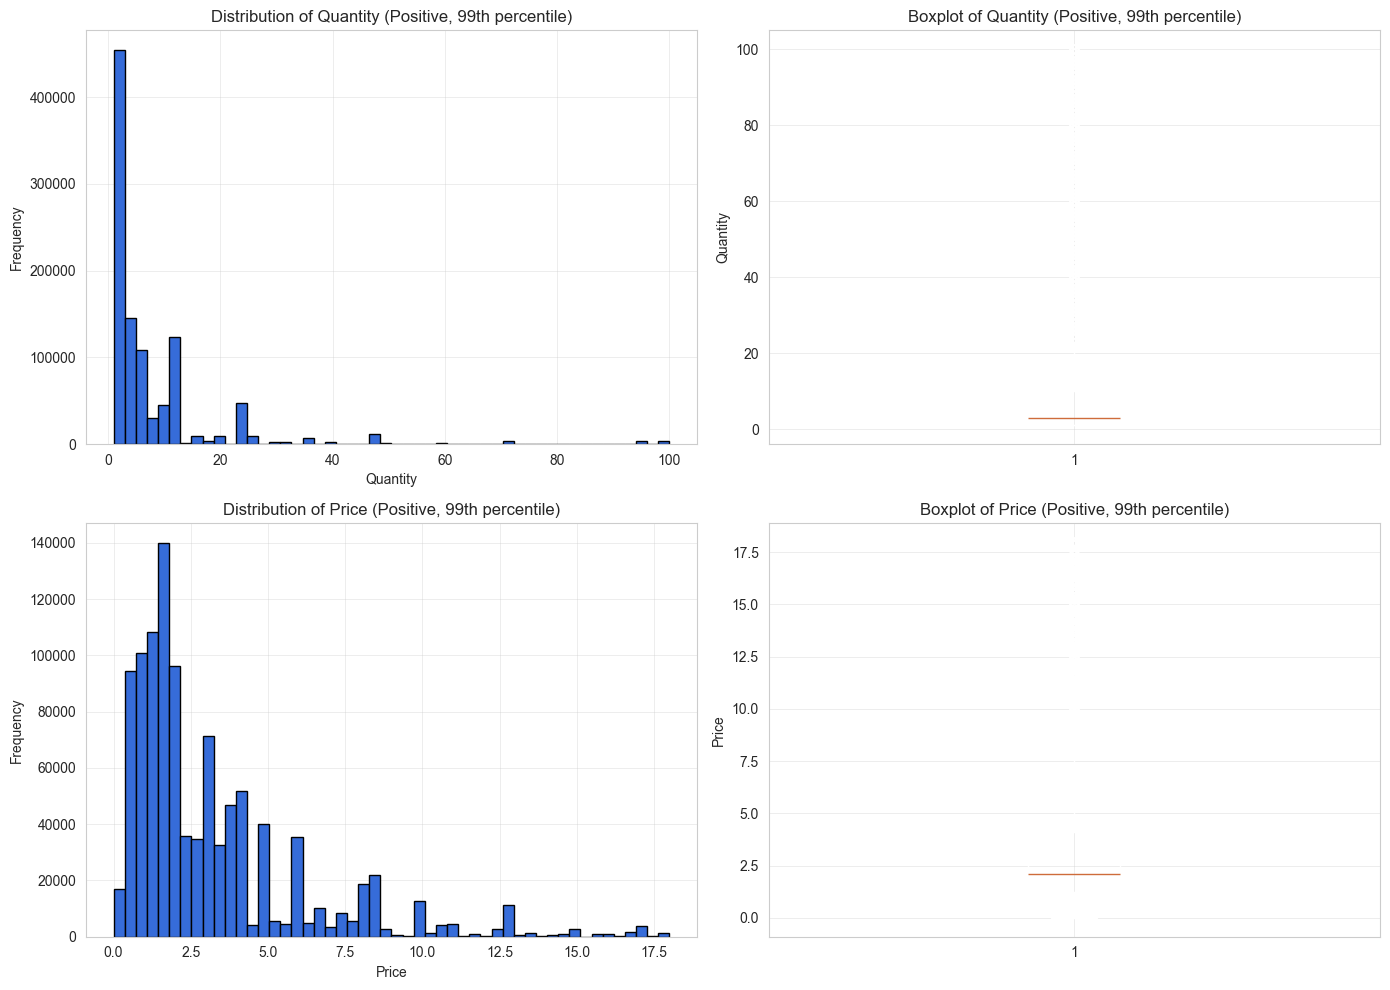

In [45]:
# Filter to reasonable ranges for visualization
# Remove extreme outliers (beyond 99th percentile)
qty_filtered = data_df[(data_df['Quantity'] > 0) & (data_df['Quantity'] <= data_df['Quantity'].quantile(0.99))]
price_filtered = data_df[(data_df['Price'] > 0) & (data_df['Price'] <= data_df['Price'].quantile(0.99))]

# Create figure with 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram for Quantity (filtered)
axes[0, 0].hist(qty_filtered['Quantity'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Quantity (Positive, 99th percentile)')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

# Boxplot for Quantity (filtered)
axes[0, 1].boxplot(qty_filtered['Quantity'])
axes[0, 1].set_title('Boxplot of Quantity (Positive, 99th percentile)')
axes[0, 1].set_ylabel('Quantity')

# Histogram for Price (filtered)
axes[1, 0].hist(price_filtered['Price'], bins=50, edgecolor='black')
axes[1, 0].set_title('Distribution of Price (Positive, 99th percentile)')
axes[1, 0].set_xlabel('Price')
axes[1, 0].set_ylabel('Frequency')

# Boxplot for Price (filtered)
axes[1, 1].boxplot(price_filtered['Price'])
axes[1, 1].set_title('Boxplot of Price (Positive, 99th percentile)')
axes[1, 1].set_ylabel('Price')

plt.tight_layout()
plt.show()

In [46]:
# Count negative values
negative_qty = data_df[data_df['Quantity'] < 0].shape[0]
negative_price = data_df[data_df['Price'] < 0].shape[0]
zero_price = data_df[data_df['Price'] == 0].shape[0]

# Calculate percentages
total_rows = len(data_df)
negative_qty_pct = (negative_qty / total_rows) * 100
negative_price_pct = (negative_price / total_rows) * 100
zero_price_pct = (zero_price / total_rows) * 100

# Display results
print("Negative and Zero Value Analysis:")
print(f"Negative Quantity: {negative_qty:,} rows ({negative_qty_pct:.2f}%)")
print(f"Negative Price: {negative_price:,} rows ({negative_price_pct:.2f}%)")
print(f"Zero Price: {zero_price:,} rows ({zero_price_pct:.2f}%)")

Negative and Zero Value Analysis:
Negative Quantity: 22,950 rows (2.15%)
Negative Price: 5 rows (0.00%)
Zero Price: 6,202 rows (0.58%)


In [47]:
# Check invoices starting with 'C' which indicates cancelled invoices
cancellation_invoices = data_df[data_df['Invoice'].str.startswith('C')]

print("Cancellation Invoice Analysis:")
print(f"Total invoices starting with 'C': {cancellation_invoices.shape[0]:,}")
print(f"Percentage of dataset: {(cancellation_invoices.shape[0] / len(data_df)) * 100:.2f}%")
print(f"\nNegative Quantity in 'C' invoices: {(cancellation_invoices['Quantity'] < 0).sum():,}")
print(f"Positive Quantity in 'C' invoices: {(cancellation_invoices['Quantity'] > 0).sum():,}")

Cancellation Invoice Analysis:
Total invoices starting with 'C': 19,494
Percentage of dataset: 1.83%

Negative Quantity in 'C' invoices: 19,493
Positive Quantity in 'C' invoices: 1


In [48]:
# Find negative quantities that are NOT in 'C' invoices
non_c_negative = data_df[(data_df['Quantity'] < 0) & (~data_df['Invoice'].str.startswith('C'))]

print("Non-'C' Negative Quantity Analysis:")
print(f"Total rows: {non_c_negative.shape[0]:,}")
print(f"\nSample of these invoices:")
print(non_c_negative[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head(10))

print(f"\nUnique Price List: {non_c_negative['Price'].value_counts()}")

Non-'C' Negative Quantity Analysis:
Total rows: 3,457

Sample of these invoices:
     Invoice StockCode      Description  Quantity  Price
263   489464     21733     85123a mixed       -96   0.00
283   489463     71477            short      -240   0.00
284   489467    85123A      21733 mixed      -192   0.00
470   489521     21646              NaN       -50   0.00
3114  489655     20683              NaN       -44   0.00
3162  489660     35956             lost     -1043   0.00
3168  489663    35605A          damages      -117   0.00
4296  489806     18010              NaN      -770   0.00
4538  489820     21133  invcd as 84879?      -720   0.00
4566  489821    85049G              NaN      -240   0.00

Unique Price List: Price
0.00    3457
Name: count, dtype: int64


In [49]:
# Find zero-price rows
zero_price_rows = data_df[data_df['Price'] == 0]

print("Zero Price Analysis:")
print(f"Total rows with Price = 0: {zero_price_rows.shape[0]:,}")
print(f"\nSample descriptions:")
print(zero_price_rows['Description'].value_counts().head(15))

Zero Price Analysis:
Total rows with Price = 0: 6,202

Sample descriptions:
Description
check                           162
?                                92
damages                          84
damaged                          81
found                            28
missing                          27
sold as set on dotcom            20
Damaged                          17
adjustment                       16
OWL DOORSTOP                     15
POLYESTER FILLER PAD 45x45cm     12
dotcom                           12
amazon                           11
POLYESTER FILLER PAD 40x40cm     10
IVORY KITCHEN SCALES             10
Name: count, dtype: int64


## STAGE 3: Data Preparation

### Summary
---
#### Data Cleaning
| Issue | Rows Removed | Reason |
|-------|-------------|--------|
| Missing Customer ID | 243,007 | Cannot analyze customer behavior without identifier |
| Returns/Cancellations (Invoice starts with "C") | 19,494 | Not purchase transactions |
| Negative Quantity (non-"C" invoices) | 3,457 | Inventory adjustments |
| Negative Price | 5 | Data errors |
| Zero Price | 6,202 | Inventory operations |
| Zero-Price Add-ons | 18 | Free items, no revenue |
| **Total Removed** | **261,840** | **24.5% of original dataset** |

**Final Clean Dataset:** 805,531 rows (75.5% retained)

#### Feature Engineering
    - Created `Revenue` column: Quantity × Price
    - Customer-Level Aggregation
        - Aggregated to 5,878 unique customers
        - Calculated RFM features:
          - Recency: Days since last purchase
          - Frequency: Count of unique orders
          - Monetary: Total revenue per customer
    - RFM Scoring:
        - Scored each dimension 1-5 using quintiles
        - Recency: 5 bins (reversed scoring — lower days = higher score)
        - Frequency: **4 bins** (1,623 customers with Frequency = 1 prevented 5th bin)
        - Monetary: 5 bins

**Customer Segments Created:**

| Segment | Count | % | Profile |
|---------|-------|---|---------|
| VIP | 1,277 | 22% | Recent, frequent, high spenders |
| Loyal | 601 | 10% | Regular, consistent buyers |
| New Customers | 951 | 16% | First/second purchase |
| Potential Loyalists | 702 | 12% | Recent but infrequent |
| At Risk | 268 | 5% | Valuable but inactive |
| Cannot Lose | 595 | 10% | High spenders who disappeared |
| Churned | 1,484 | 25% | Low R, F, M — likely lost |

**Key Insight:** 40% of customers are inactive or at-risk (Churned 25% + At Risk 5% + Cannot Lose 10%)


#### Step 3.1: Data Cleaning

In [50]:
# Create a clean dataset
data_clean = data_df.copy()

# Remove rows with missing Customer ID
data_clean = data_clean[data_clean['Customer ID'].notna()]

# Remove returns/cancellations (Invoice starts with 'C')
data_clean = data_clean[~data_clean['Invoice'].str.startswith('C')]

# Remove rows with negative or zero Quantity
data_clean = data_clean[data_clean['Quantity'] > 0]

# Remove rows with negative or zero Price
data_clean = data_clean[data_clean['Price'] > 0]

# Display results
print("Data Cleaning Summary:")
print(f"Original dataset: {len(data_df):,} rows")
print(f"After removing missing Customer ID: {len(data_clean):,} rows")
print(f"Rows removed: {len(data_df) - len(data_clean):,} ({((len(data_df) - len(data_clean)) / len(data_df)) * 100:.2f}%)")

Data Cleaning Summary:
Original dataset: 1,067,371 rows
After removing missing Customer ID: 805,549 rows
Rows removed: 261,822 (24.53%)


In [51]:
# Verify cleaning
print("Cleaning Verification:")
print(f"Rows with missing Customer ID: {data_clean['Customer ID'].isna().sum():,}")
print(f"Rows with Invoice starting 'C': {data_clean['Invoice'].str.startswith('C').sum():,}")
print(f"Rows with Quantity <= 0: {(data_clean['Quantity'] <= 0).sum():,}")
print(f"Rows with Price <= 0: {(data_clean['Price'] <= 0).sum():,}")
print(f"\nCleaned Dataset Shape: {data_clean.shape}")
print(f"\nCleaned data summary statistics:")
print(data_clean[['Quantity', 'Price']].describe())

Cleaning Verification:
Rows with missing Customer ID: 0
Rows with Invoice starting 'C': 0
Rows with Quantity <= 0: 0
Rows with Price <= 0: 0

Cleaned Dataset Shape: (805549, 8)

Cleaned data summary statistics:
       Quantity     Price
count 805549.00 805549.00
mean      13.29      3.21
std      143.63     29.20
min        1.00      0.00
25%        2.00      1.25
50%        5.00      1.95
75%       12.00      3.75
max    80995.00  10953.50


In [52]:
# Check how many rows have very low prices (below 0.01)
low_price = data_clean[data_clean['Price'] < 0.01]

print(f"Rows with Price < 0.01: {len(low_price):,}")
print(f"\nSample:")
print(low_price[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head(10))

Rows with Price < 0.01: 18

Sample:
       Invoice StockCode                 Description  Quantity  Price
62299   494914      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
74731   496222      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
77702   496473      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
79794   496643      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
90798   497935      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
97716   498562      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
101718  499056      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
104480  499399      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
123947  501176      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00
156809  504332      PADS  PADS TO MATCH ALL CUSHIONS         1   0.00


In [53]:
# Remove remaining zero price rows
data_clean = data_clean[data_clean['Price'] >= 0.01]

# Confirm
print(f"Rows removed: {18}")
print(f"Final cleaned dataset shape: {data_clean.shape}")
print(f"Min Price: {data_clean['Price'].min()}")

Rows removed: 18
Final cleaned dataset shape: (805531, 8)
Min Price: 0.03


#### Step 3.2 Feature Engineering

In [54]:
# Create Revenue column (Quantity x Price)
data_clean['Revenue'] = data_clean['Quantity'] * data_clean['Price']

# Verify
print(f"Revenue column created successfully")
print(f"\nSample:")
print(data_clean[['Invoice', 'Quantity', 'Price', 'Revenue']].head())
print(f"\nRevenue Summary:")
print(data_clean['Revenue'].describe())

Revenue column created successfully

Sample:
  Invoice  Quantity  Price  Revenue
0  489434        12   6.95    83.40
1  489434        12   6.75    81.00
2  489434        12   6.75    81.00
3  489434        48   2.10   100.80
4  489434        24   1.25    30.00

Revenue Summary:
count   805531.00
mean        22.03
std        224.04
min          0.06
25%          4.95
50%         11.85
75%         19.50
max     168469.60
Name: Revenue, dtype: float64


In [55]:
# Define snapshot date (day after last transaction)
snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Snapshot date: {snapshot_date}")

# Aggregate to customer level
rfm = data_clean.groupby('Customer ID').agg(
    last_purchase_date=('InvoiceDate', 'max'),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Calculate Recency
rfm['Recency'] = (snapshot_date - rfm['last_purchase_date']).dt.days

# Drop last_purchase_date (no longer needed)
rfm = rfm.drop(columns=['last_purchase_date'])

# Display results
print(f"\nRFM Table Shape: {rfm.shape}")
print(f"\nSample:")
print(rfm.head())

Snapshot date: 2011-12-10 12:50:00

RFM Table Shape: (5878, 4)

Sample:
   Customer ID  Frequency  Monetary  Recency
0     12346.00         12  77556.46      326
1     12347.00          8   5633.32        2
2     12348.00          5   2019.40       75
3     12349.00          4   4428.69       19
4     12350.00          1    334.40      310


In [62]:
# Score Recency (5 bins, lower days = better = higher score)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# Score Frequency (4 bins, higher = better)
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=5, labels=[1, 2, 3, 4], duplicates='drop')

# Score Monetary (5 bins, higher = better)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Combine scores into single RFM score string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Display results
print("RFM Scoring Complete")
print(f"\nSample:")
print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

RFM Scoring Complete

Sample:
   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12346.00      326         12  77556.46       2       4       5       245
1     12347.00        2          8   5633.32       5       3       5       535
2     12348.00       75          5   2019.40       3       3       4       334
3     12349.00       19          4   4428.69       5       2       5       525
4     12350.00      310          1    334.40       2       1       2       212
5     12351.00      375          1    300.93       2       1       2       212
6     12352.00       36         10   2849.84       4       4       4       444
7     12353.00      204          2    406.76       2       1       2       212
8     12354.00      232          1   1079.40       2       1       3       213
9     12355.00      214          2    947.61       2       1       3       213


In [64]:
# Define segment mapping based on RFM scores
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 3 and m >= 4:
        return 'VIP'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose'
    else:
        return 'Churned'

# Apply segment assignment
rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Display segment distribution
print("Segment Distribution:")
print(rfm['Segment'].value_counts())
print(f"\nTotal Customers: {len(rfm)}")

Segment Distribution:
Segment
Churned                1484
VIP                    1277
New Customers           951
Potential Loyalists     702
Loyal                   601
Cannot Lose             595
At Risk                 268
Name: count, dtype: int64

Total Customers: 5878


In [65]:
# Save cleaned transaction data
data_clean.to_csv('../../datasets/data_clean.csv', index=False)

# Save RFM table
rfm.to_csv('../../datasets/online_retail_2_rfm_segments.csv', index=False)

print("Data saved successfully:")
print(f"- data_clean.csv: {data_clean.shape}")
print(f"- rfm_segments.csv: {rfm.shape}")

Data saved successfully:
- data_clean.csv: (805531, 9)
- rfm_segments.csv: (5878, 9)


## Stage 4: Modeling — Churn Prediction